In [1]:
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl
import matplotlib.pyplot as plt

In [2]:
traffic_density = ctrl.Antecedent(np.arange(0, 41, 1), 'traffic_density')
queue_length = ctrl.Antecedent(np.arange(0, 21, 1), 'queue_length')
green_time = ctrl.Consequent(np.arange(10, 61, 1), 'green_time')

In [3]:
# Traffic Density
traffic_density['low'] = fuzz.trimf(traffic_density.universe, [0, 0, 20])
traffic_density['medium'] = fuzz.trimf(traffic_density.universe, [0, 20, 40])
traffic_density['high'] = fuzz.trimf(traffic_density.universe, [20, 40, 40])

# Queue Length
queue_length['short'] = fuzz.trimf(queue_length.universe, [0, 0, 10])
queue_length['medium'] = fuzz.trimf(queue_length.universe, [0, 10, 20])
queue_length['long'] = fuzz.trimf(queue_length.universe, [10, 20, 20])

# Green Signal Duration
green_time['short'] = fuzz.trimf(green_time.universe, [10, 10, 35])
green_time['medium'] = fuzz.trimf(green_time.universe, [10, 35, 60])
green_time['long'] = fuzz.trimf(green_time.universe, [35, 60, 60])

C:\Users\wassi\AppData\Local\Programs\Python\Python313\Lib\site-packages\skfuzzy\control\fuzzyvariable.py:125: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


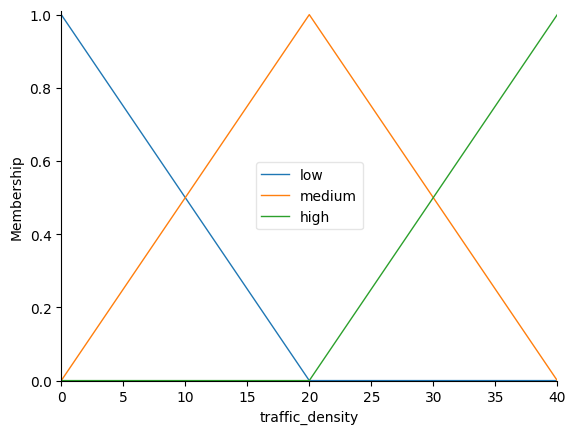

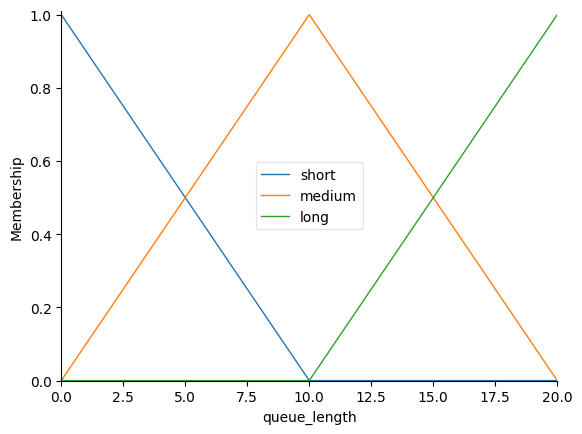

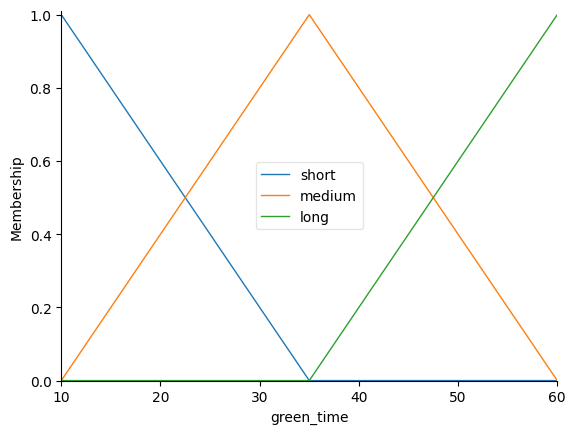

In [4]:
traffic_density.view()
plt.show()

queue_length.view()
plt.show()

green_time.view()
plt.show()

In [5]:
rule1 = ctrl.Rule(traffic_density['low'] & queue_length['short'], green_time['short'])
rule2 = ctrl.Rule(traffic_density['low'] & queue_length['medium'], green_time['short'])
rule3 = ctrl.Rule(traffic_density['low'] & queue_length['long'], green_time['medium'])

rule4 = ctrl.Rule(traffic_density['medium'] & queue_length['short'], green_time['medium'])
rule5 = ctrl.Rule(traffic_density['medium'] & queue_length['medium'], green_time['medium'])
rule6 = ctrl.Rule(traffic_density['medium'] & queue_length['long'], green_time['long'])

rule7 = ctrl.Rule(traffic_density['high'] & queue_length['short'], green_time['medium'])
rule8 = ctrl.Rule(traffic_density['high'] & queue_length['medium'], green_time['long'])
rule9 = ctrl.Rule(traffic_density['high'] & queue_length['long'], green_time['long'])

In [6]:
traffic_ctrl = ctrl.ControlSystem([
    rule1, rule2, rule3,
    rule4, rule5, rule6,
    rule7, rule8, rule9
])

traffic_sim = ctrl.ControlSystemSimulation(traffic_ctrl)

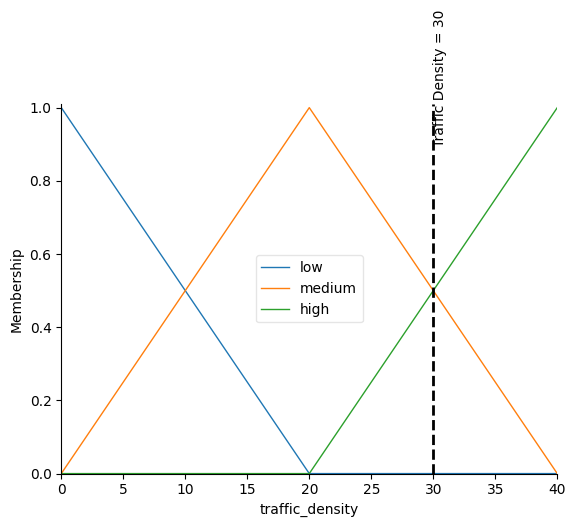

In [7]:
traffic_density.view()

plt.axvline(x=30, color='black', linestyle='--', linewidth=2)
plt.text(30, 0.9, 'Traffic Density = 30', rotation=90)

plt.show()

In [8]:
medium_value = fuzz.interp_membership(traffic_density.universe,
                                      traffic_density['medium'].mf,
                                      30)

high_value = fuzz.interp_membership(traffic_density.universe,
                                    traffic_density['high'].mf,
                                    30)

print("Medium membership:", medium_value)
print("High membership:", high_value)

Medium membership: 0.5
High membership: 0.5


In [9]:
medium_value = fuzz.interp_membership(queue_length.universe,
                                      queue_length['medium'].mf,
                                      14)

long_value = fuzz.interp_membership(queue_length.universe,
                                    queue_length['long'].mf,
                                    14)

print("Medium membership:", medium_value)
print("Long membership:", long_value)

Medium membership: 0.6
Long membership: 0.4


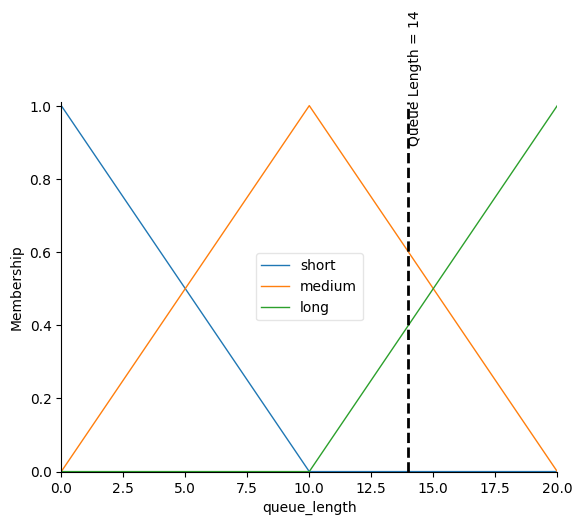

In [10]:
queue_length.view()

plt.axvline(x=14, color='black', linestyle='--', linewidth=2)
plt.text(14, 0.9, 'Queue Length = 14', rotation=90)

plt.show()

In [11]:
traffic_sim.input['traffic_density'] = 30
traffic_sim.input['queue_length'] = 14

traffic_sim.compute()

In [12]:
print("Recommended green signal duration:", traffic_sim.output['green_time'])

Recommended green signal duration: 37.976190476190474


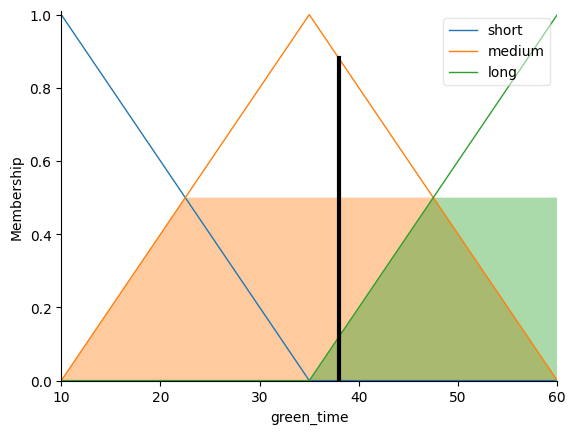

In [13]:
green_time.view(sim=traffic_sim)
plt.show()